In [68]:
%matplotlib inline
import torch
import torchvision
from torch import nn
from torch.nn import functional as F
import torchvision.transforms as transforms
from torch.utils import data
import matplotlib.pyplot as plt
import numpy as np

# 模型架构——ResNet-18

In [69]:
class Accumulator:
    def __init__(self, n):
        self.data = [0.0] * n
    def add(self, *args):
        self.data = [a + float(b) for a, b in zip(self.data, args)]
    def reset(self):
        self.data = [0.0] * len(self.data)
    def __getitem__(self, idx):
        return self.data[idx]

In [70]:
class Residual(nn.Module):
    def __init__(self, input_channels, num_channels, use_1x1conv = False, strides = 1):
        super().__init__()
        self.conv1 = nn.Conv2d(input_channels, num_channels, kernel_size = 3, padding = 1, stride = strides)
        self.conv2 = nn.Conv2d(num_channels, num_channels, kernel_size = 3, padding = 1)
        if use_1x1conv:
            self.conv3 = nn.Conv2d(input_channels, num_channels, kernel_size = 1, stride = strides)
        else:
            self.conv3 = None
        self.bn1 = nn.BatchNorm2d(num_channels)
        self.bn2 = nn.BatchNorm2d(num_channels)

    def forward(self, X):
        Y = F.relu(self.bn1(self.conv1(X)))
        Y = self.bn2(self.conv2(Y))
        if self.conv3:
            X = self.conv3(X)
        Y += X
        return F.relu(Y)

In [71]:
b1 = nn.Sequential(nn.Conv2d(3, 64, kernel_size = 7, stride = 2, padding = 3),
                 nn.BatchNorm2d(64), nn.ReLU(),
                 nn.MaxPool2d(kernel_size = 3, stride = 2, padding = 1))

In [72]:
def resnet_block(input_channels, num_channels, num_residuals, 
                 first_block = False):
    blk = []
    for i in range(num_residuals):
        if i == 0 and not first_block:
            blk.append(Residual(input_channels, num_channels, 
                                use_1x1conv = True, strides = 2))
        else:
            blk.append(Residual(num_channels, num_channels))
    return blk
        

In [73]:
b2 = nn.Sequential(*resnet_block(64, 64, 2, first_block = True))
b3 = nn.Sequential(*resnet_block(64, 128, 2))
b4 = nn.Sequential(*resnet_block(128, 256, 2))
b5 = nn.Sequential(*resnet_block(256, 512, 2))

In [74]:
net = nn.Sequential(b1, b2, b3, b4, b5,
                   nn.AdaptiveAvgPool2d((1, 1)),
                   nn.Flatten(), nn.Dropout(0.3), nn.Linear(512, 2))

# 图像增广

## 作图

In [75]:
def show_images(imgs, num_rows, num_cols, titles=None, scale=1.5):
    """Plot a list of images.

    Defined in :numref:`sec_utils`"""
    figsize = (num_cols * scale, num_rows * scale)
    _, axes = plt.subplots(num_rows, num_cols, figsize=figsize)
    axes = axes.flatten()
    for i, (ax, img) in enumerate(zip(axes, imgs)):
        if torch.is_tensor(img):
            # 将 (C, H, W) 转换为 (H, W, C)
            img = img.permute(1, 2, 0).cpu().numpy()

        ax.imshow((img*225).astype(np.uint8))
        ax.axes.get_xaxis().set_visible(False)
        ax.axes.get_yaxis().set_visible(False)
        if titles:
            ax.set_title(titles[i])
    return axes

In [76]:
def apply(img, aug, num_rows = 2, num_cols = 4, scale = 1):
    y = [aug(img) for _ in range(num_rows * num_cols)]
    show_images(y, num_rows, num_cols, scale = scale)

In [77]:
train_augs = torchvision.transforms.Compose([
    torchvision.transforms.Resize((224, 224)),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])
test_augs = torchvision.transforms.Compose([
    torchvision.transforms.Resize((224, 224)),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

# 加载数据

In [78]:
def load_data(batch_size, resize=None, train_augs=None, test_augs=None):
    train_dir = '/kaggle/input/datasets/tongpython/cat-and-dog/training_set/training_set'
    
    # 1. 先加载原始数据集（不应用任何变换）
    full_dataset = torchvision.datasets.ImageFolder(root=train_dir, transform=None)
    
    # 2. 划分训练集和验证集（基于索引）
    val_size = int(len(full_dataset) * 0.3)
    train_size = len(full_dataset) - val_size
    train_subset, val_subset = data.random_split(full_dataset, [train_size, val_size])
    
    # 3. 定义一个包装类，为每个子集单独应用变换
    class TransformSubset(data.Dataset):
        def __init__(self, subset, transform):
            self.subset = subset
            self.transform = transform
        def __len__(self):
            return len(self.subset)
        def __getitem__(self, idx):
            img, label = self.subset[idx]
            if self.transform:
                img = self.transform(img)
            return img, label
    
    # 4. 分别包装训练集和验证集，应用不同的变换
    train_dataset = TransformSubset(train_subset, train_augs)
    val_dataset = TransformSubset(val_subset, test_augs)
    
    # 5. 创建 DataLoader
    train_loader = data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, val_loader

# 训练函数

In [79]:
#返回正确数
def accuracy(y_hat, y):
    if y_hat.ndim > 1:
        y_hat = y_hat.argmax(dim=1)
    return (y_hat == y).sum().item()

def evaluate_accuracy_gpu(net, data_iter, device = None):
    if isinstance(net, nn.Module):
        net.eval()
        if not device:
            device = next(iter(net.parameters())).device
    metric = Accumulator(2)
    with torch.no_grad():
        for X, y in data_iter:
            if isinstance(X, list):
                X =[x.to(device) for x in X]
            else:
                X = X.to(device)

            y = y.to(device)
            metric.add(accuracy(net(X), y), y.numel())
    return metric[0] / metric[1]

In [80]:
def train(net, train_iter, test_iter, num_epochs, lr, device):
    #使用xavier权重初始化
    def init_weights(m):
        if type(m) == nn.Linear or type(m) == nn.Conv2d:
            nn.init.xavier_uniform_(m.weight)
    net.apply(init_weights)
    print('training on', device)
    net.to(device)
    optimizer = torch.optim.SGD(net.parameters(), lr = lr, momentum=0.9, weight_decay=1e-4)
    loss = nn.CrossEntropyLoss()
    train_losses, train_accs, test_accs = [], [], []
    best_acc = 0

    for epoch in range(num_epochs):
        metric= Accumulator(3)
        for i,(x, y) in enumerate(train_iter):
            optimizer.zero_grad()
            x, y = x.to(device), y.to(device)
            y_hat = net(x)
            l = loss(y_hat, y)
            l.backward()
            optimizer.step()
            with torch.no_grad():
                metric.add(l * x.shape[0], accuracy(y_hat, y), x.shape[0])
            train_l = metric[0] / metric[2]
            train_acc = metric[1] / metric[2]
            
            
        test_acc = evaluate_accuracy_gpu(net, test_iter)
        if test_acc > best_acc:
            best_acc = test_acc
            torch.save(net.state_dict(), 'best_cat_dog_model.pth')
        print(f'Epoch {epoch+1}: loss={train_l:.4f}, train_acc={train_acc:.4f}, test_acc={test_acc:.4f}')
        train_losses.append(train_l)
        train_accs.append(train_acc)
        test_accs.append(test_acc)
    return train_losses, train_accs, test_accs

# 运行

## 设置超参数

In [81]:
lr, num_epochs, batch_size = 0.001, 50, 64
train_iter, test_iter = load_data(batch_size, resize = 224, train_augs=train_augs, test_augs=test_augs)

### 多种方式结合

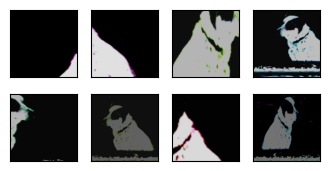

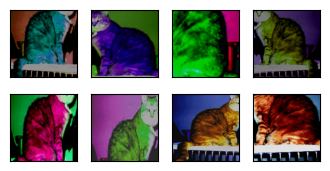

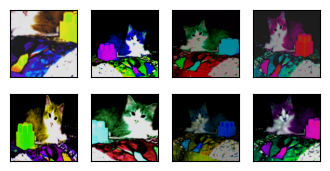

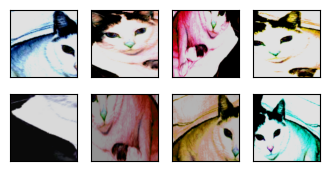

In [82]:
augs = torchvision.transforms.Compose([
    torchvision.transforms.RandomHorizontalFlip(), color_aug, shape_aug])
for i in range(n):
    apply(images[i], augs)

## 开始训练 

In [83]:
train_losses, train_accs, test_accs = [], [], []
train_losses, train_accs, test_accs = train(net, train_iter, test_iter, num_epochs, lr, torch.device('cuda' if torch.cuda.is_available() else 'cpu'))

training on cuda
Epoch 1: loss=0.7892, train_acc=0.5651, test_acc=0.5602
Epoch 2: loss=0.6872, train_acc=0.5803, test_acc=0.5864
Epoch 3: loss=0.6420, train_acc=0.6221, test_acc=0.6543
Epoch 4: loss=0.6234, train_acc=0.6392, test_acc=0.6818
Epoch 5: loss=0.5846, train_acc=0.6909, test_acc=0.7130
Epoch 6: loss=0.5738, train_acc=0.6929, test_acc=0.7085
Epoch 7: loss=0.5522, train_acc=0.7116, test_acc=0.7243
Epoch 8: loss=0.5368, train_acc=0.7254, test_acc=0.7434
Epoch 9: loss=0.5386, train_acc=0.7202, test_acc=0.7418
Epoch 10: loss=0.4983, train_acc=0.7523, test_acc=0.7180
Epoch 11: loss=0.4945, train_acc=0.7530, test_acc=0.7705
Epoch 12: loss=0.4887, train_acc=0.7564, test_acc=0.7751
Epoch 13: loss=0.4624, train_acc=0.7762, test_acc=0.7647
Epoch 14: loss=0.4428, train_acc=0.7891, test_acc=0.7072
Epoch 15: loss=0.4175, train_acc=0.8030, test_acc=0.7843
Epoch 16: loss=0.4017, train_acc=0.8180, test_acc=0.7718
Epoch 17: loss=0.4047, train_acc=0.8166, test_acc=0.7838
Epoch 18: loss=0.4075, 

# 作图

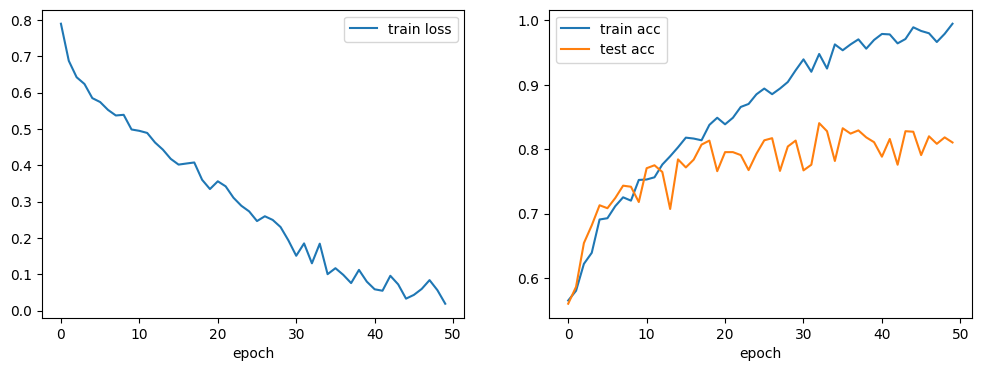

In [84]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(train_losses, label='train loss')
plt.xlabel('epoch')
plt.legend()
plt.subplot(1,2,2)
plt.plot(train_accs, label='train acc')
plt.plot(test_accs, label='test acc')
plt.xlabel('epoch')
plt.legend()
plt.show()